# Preamble

In [1]:
import Pkg;
Pkg.add("ForwardDiff"); 
Pkg.add("Plots"); 
Pkg.add("LaTeXStrings"); 
Pkg.add("DifferentialEquations"); 
Pkg.add("Roots"); 
Pkg.add("QuadGK"); 
Pkg.add("HCubature");
Pkg.add("MultiQuad");
Pkg.add("Interpolations");
Pkg.add("DataInterpolations");
Pkg.add("Dierckx");
Pkg.add("SpecialFunctions");
Pkg.add("LinearAlgebra");
Pkg.add("DelimitedFiles");

   Resolving package versions...
   Installed StaticArraysCore ──── v1.4.4
   Installed IrrationalConstants ─ v0.2.6
   Installed DocStringExtensions ─ v0.9.5
   Installed NaNMath ───────────── v1.1.3
   Installed MacroTools ────────── v0.5.16
   Installed ForwardDiff ───────── v1.3.3
   Installed SpecialFunctions ──── v2.7.2
    Updating `~/.julia/environments/v1.12/Project.toml`
  [f6369f11] + ForwardDiff v1.3.3
    Updating `~/.julia/environments/v1.12/Manifest.toml`
  [bbf7d656] + CommonSubexpressions v0.3.1
  [163ba53b] + DiffResults v1.1.0
  [b552c78f] + DiffRules v1.15.1
  [ffbed154] + DocStringExtensions v0.9.5
  [f6369f11] + ForwardDiff v1.3.3
  [92d709cd] + IrrationalConstants v0.2.6
  [2ab3a3ac] + LogExpFunctions v0.3.29
  [1914dd2f] + MacroTools v0.5.16
  [77ba4419] + NaNMath v1.1.3
  [276daf66] + SpecialFunctions v2.7.2
  [1e83bf80] + StaticArraysCore v1.4.4
  [efe28fd5] + OpenSpecFun_jll v0.5.6+0
  [37e2e46d] + LinearAlgebra v1.12.0
  [4536629a] + OpenBLAS_jll v0.3.29+0
 

In [1]:
using ForwardDiff, Plots, LaTeXStrings, DifferentialEquations, Roots, QuadGK, HCubature, MultiQuad, Interpolations, DataInterpolations, Dierckx, SpecialFunctions, LinearAlgebra, DelimitedFiles
default()
default(framestyle=:box, guidefontsize=14, titlefontsize=14, tickfontsize=12, legendfontsize=12, legend=false, linewidth=3)

In [2]:
Mpl = 2.435e18 # reduced Planck mass in GeV
c = 299792458 # speed of light in m/s
KinGeV = (1.160e4)^-1 * 10^-9 # Kelvin in GeV
Mpcinm = 3.086e16 * 10^6 # Mpc in m
GeVinminv = 10^9/(1.973e-7) # GeV in m^-1
GeVinMpcinv = GeVinminv * Mpcinm # GeV in Mpc^-1
MpcinvinHz = c/Mpcinm # Mpc^inv in Hz
yrins = 365.2422 * 24 * 60 * 60 # yr in s

Or0h2 = 4.2e-5 # current radiation density parameter * h^2
Hubblh = 0.674 # normalised Hubble parameter h

T0 = 2.725*KinGeV # current temperature
grho0 = 3.383 # current grho
gs0 = 3.931 # current gs

3.931

In [3]:
Threads.nthreads()

4

# Background

## calculation

In [7]:
ai = [1, 1.11724, 3.12672e-1, -4.68049e-2, -2.65004e-2, -1.19760e-3, 1.82812e-4, 1.36436e-4, 8.55051e-5, 1.22840e-5, 3.82259e-7, -6.87035e-9];
bi = [1.43382e-2, 1.37559e-2, 2.92108e-3, -5.38533e-4, -1.62496e-4, -2.87906e-5, -3.84278e-6, 2.78776e-6, 7.40342e-7, 1.17210e-7, 3.72499e-9, -6.74107e-11];
ci = [1, 6.07869e-1, -1.54485e-1, -2.24034e-1, -2.82147e-2, 2.90620e-2, 6.86778e-3, -1.00005e-3, -1.69104e-4, 1.06301e-5, 1.69528e-6, -9.33311e-8];
di = [7.07388e1, 9.18011e1, 3.31892e1, -1.39779, -1.52558, -1.97857e-2, -1.60146e-1, 8.22615e-5, 2.02651e-2, -1.82134e-5, 7.83943e-5, 7.13518e-5];

In [9]:
Tth = 0.12; # temperature separation in GeV

In [11]:
grhohigh(T) = sum([ai[i]*log(T)^(i - 1) for i=1:12]) / sum([bi[i]*log(T)^(i - 1) for i=1:12]); # eff. DoF for energy density for T > 0.12 GeV
gshigh(T) = grhohigh(T) / (1 + sum([ci[i]*log(T)^(i - 1) for i=1:12]) / sum([di[i]*log(T)^(i - 1) for i=1:12])); # eff. DoF for entropy for T > 0.12 GeV

In [13]:
rhohigh(T) = π^2/30*grhohigh(T)*T^4; # energy density for T > 0.12 GeV
shigh(T) = 2*π^2/45*gshigh(T)*T^3; # entropy for T > 0.12 GeV
phigh(T) = T*shigh(T) - rhohigh(T); # pressure for T > 0.12 GeV

In [15]:
# some fitting functions
Sfit(x) = 1 + 7/4*exp(-1.0419*x) * (1 + 1.034*x + 0.456426*x^2 + 0.0595249*x^3);
frho(x) = exp(-1.04855*x) * (1 + 1.03757*x + 0.508630*x^2 + 0.0893988*x^3);
brho(x) = exp(-1.03149*x) * (1 + 1.03317*x + 0.398264*x^2 + 0.0648056*x^3);
fs(x) = exp(-1.04190*x) * (1 + 1.03400*x + 0.456426*x^2 + 0.0595248*x^3);
bs(x) = exp(-1.03365*x) * (1 + 1.03397*x + 0.342548*x^2 + 0.0506182*x^3);

In [17]:
# mass params. in GeV
me = 511e-6;
mmu = 0.1056;
mpi0 = 0.13;
mpipm = 0.140;
m1 = 0.5;
m2 = 0.77;
m3 = 1.2;
m4 = 2;

In [19]:
# neutrino temperature
Tnu(T) = (4/11)^(1/3) * Sfit(me/T)^(1/3) * T;

In [21]:
grhogammalow(T) = 2.030 + 3.495*frho(me/T) + 3.446*frho(mmu/T) + 1.05*brho(mpi0/T) + 2.08*brho(mpipm/T) + 4.165*brho(m1/T) + 30.55*brho(m2/T) + 89.4*brho(m3/T) + 8209*brho(m4/T); # eff. DoF for photon energy density for T < 0.12 GeV
gsgammalow(T) = 2.008 + 3.442*fs(me/T) + 3.468*fs(mmu/T) + 1.034*bs(mpi0/T) + 2.068*bs(mpipm/T) + 4.16*bs(m1/T) + 30.55*bs(m2/T) + 90*bs(m3/T) + 6209*bs(m4/T); # eff. DoF for photon entropy for T < 0.12 GeV
grhonulow(T) = 1.353*Sfit(me/T)^(4/3); # eff. DoF for neutrino energy density for T < 0.12 GeV
gsnulow(T) = 1.923*Sfit(me/T); # eff. DoF for neutrino entropy for T < 0.12 GeV

In [23]:
# T < 0.12 GeV
rhogammalow(T) = π^2/30*grhogammalow(T)*T^4; # photon energy density
sgammalow(T) = 2*π^2/45*gsgammalow(T)*T^3; # photon entropy
rhonulow(T) = π^2/30*grhonulow(T)*T^4; # neutrino energy density
snulow(T) = 2*π^2/45*gsnulow(T)*T^3; # neutrino entropy
pgammalow(T) = T*sgammalow(T) - rhogammalow(T); # photon pressure
pnulow(T) = Tnu(T)*snulow(T) - rhonulow(T); # neutrino pressure
rholow(T) = rhogammalow(T) + rhonulow(T); # total energy density
plow(T) = pgammalow(T) + pnulow(T); # total pressure

In [25]:
function grho(T) # eff. DoF for energy density
    if T >= Tth
        return grhohigh(T)
    else
        return grhogammalow(T) + grhonulow(T)
    end
end;

function grhop(T) # T-derivative of grho
    if T >= Tth
        return ForwardDiff.derivative(grhohigh,T)
    else
        return ForwardDiff.derivative(grhogammalow,T) + ForwardDiff.derivative(grhonulow,T)
    end
end;

function gs(T) # eff. DoF for entropy
    if T >= Tth
        return gshigh(T)
    else
        return gsgammalow(T) + gsnulow(T)
    end
end;

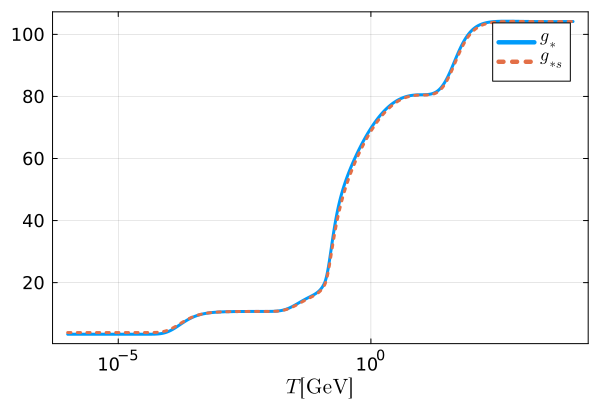

In [27]:
Tlist = [10^i for i=-6:0.01:4]
plot(grho, Tlist, xscale=:log10, label=L"$g_*$", xlabel=L"$T\,[\mathrm{GeV}]$", legend=true)
plot!(gs, Tlist, label=L"$g_{*s}$", linestyle=:dot)

In [28]:
function rho(T) # energy density
    if T >= Tth
        return rhohigh(T)
    else 
        return rholow(T)
    end
end;

function press(T) # pressure
    if T >= Tth
        return phigh(T)
    else
        return plow(T)
    end
end;

In [29]:
EoSw(T) = press(T)/rho(T); # equation-of-state param. w

function cs2(T) # sound speed squared
    if T >= Tth
        return ForwardDiff.derivative(phigh,T)/ForwardDiff.derivative(rhohigh,T)
    else
        return ForwardDiff.derivative(plow,T)/ForwardDiff.derivative(rholow,T)
    end
end;

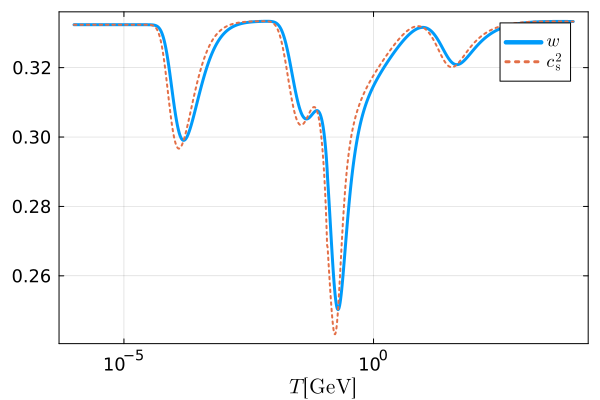

In [30]:
plot(EoSw, Tlist, xscale=:log10, label=L"$w$", xlabel=L"$T\,[\mathrm{GeV}]$", legend=true)
plot!(cs2, Tlist, label=L"$c_\mathrm{s}^2$", linestyle=:dot, linewidth=:2)

In [31]:
T0 = 2.725*KinGeV; # current temperature
grho0 = grho(T0); # current grho
gs0 = gs(T0); # current gs

In [32]:
calH(T, scalea) = scalea * sqrt(rho(T)/3/Mpl^2) * GeVinMpcinv; # conformal Hubble in Mpc^-1

In [39]:
Ti = 1e6; # initial temperature
scaleai = (gs0/gs(Ti))^(1/3)*T0/Ti; # temporal initial scale factor 
etai = 1/calH(Ti, scaleai); # initial conformal time

etaf = 10; # final conformal time

In [41]:
etai

5.842207902333349e-14

In [43]:
function bgEoM(du,u,p,lneta) # u[1] = T, u[2] = scalea
    du[1] = -3*exp(lneta)*(1 + EoSw(u[1])) * calH(u[1], u[2]) * grho(u[1]) / (grhop(u[1]) + 4*grho(u[1])/u[1])
    du[2] = exp(lneta)*u[2]*calH(u[1],u[2])
end;

ui = [Ti,scaleai];
lnetaspan = (log(etai),log(etaf));
bgprob = ODEProblem(bgEoM,ui,lnetaspan);
@time bgsol = solve(bgprob,Tsit5(),reltol=1e-10,abstol=1e-10);

  0.987515 seconds (6.08 M allocations: 165.787 MiB, 20.25% gc time, 75.64% compilation time)


In [45]:
Tsol(eta) = bgsol(log(eta))[1];
asol(eta) = bgsol(log(eta))[2];

In [47]:
norm = Tsol(etaf)/T0*asol(etaf); # renormalisation factor so that a0 = 1
anorm(eta) = asol(eta/norm)/norm; # renormalised scale factor
Tnorm(eta) = Tsol(eta/norm); # T with the renormalised eta
calHnorm(eta) = calH(Tnorm(eta), anorm(eta)); # calH with the renormalised eta
rhoQnorm(eta) = rho(Tnorm(eta))^(1/4)
af = anorm(norm*etaf); # renormalised scale factor at the final time
calHf = calHnorm(norm*etaf); # calH at the final time

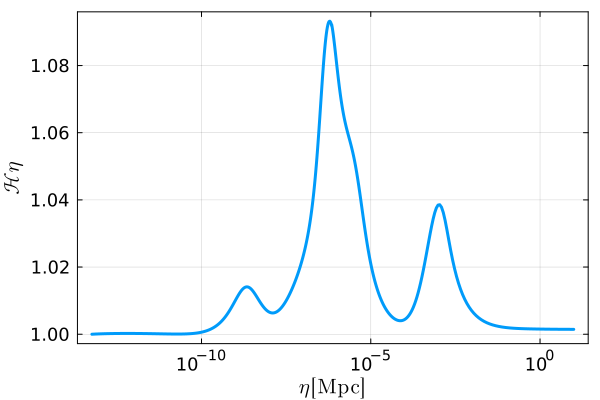

In [49]:
etalist = [norm*exp(i) for i in bgsol.t];
plot(etalist, map(x -> x*calHnorm(x), etalist), xscale=:log10, xlabel=L"$\eta\,[\mathrm{Mpc}]$", ylabel=L"$\mathcal{H}\eta$", legend=false)

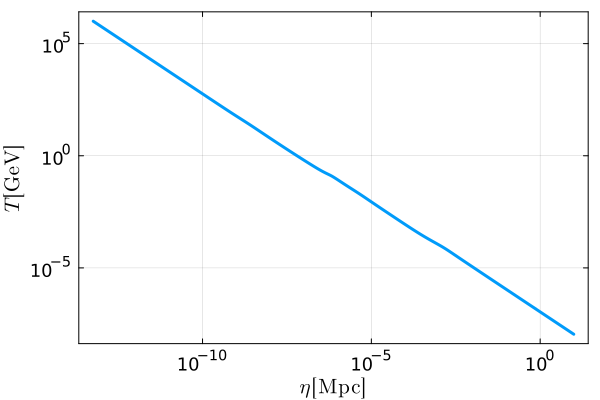

In [51]:
plot(Tnorm, etalist, xscale=:log10, yscale=:log10, xlabel=L"$\eta\,[\mathrm{Mpc}]$", ylabel=L"$T\,[\mathrm{GeV}]$", legend=false)

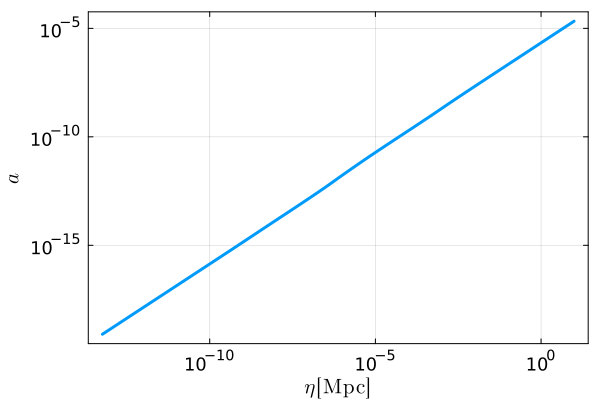

In [53]:
plot(anorm, etalist, xscale=:log10, yscale=:log10, xlabel=L"$\eta\,[\mathrm{Mpc}]$", ylabel=L"$a$", legend=false)

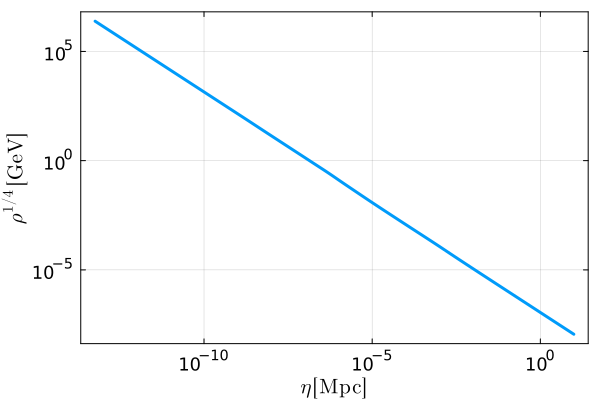

In [55]:
plot(rhoQnorm, etalist, xscale=:log10, yscale=:log10, xlabel=L"$\eta\,[\mathrm{Mpc}]$", ylabel=L"$\rho^{1/4}\,[\mathrm{GeV}]$")

In [57]:
EoSwsol(eta) = EoSw(Tnorm(eta));
cs2sol(eta) = cs2(Tnorm(eta));
grhosol(eta) = grho(Tnorm(eta));
gssol(eta) = gs(Tnorm(eta));

In [59]:
rhoQis1e4(eta) = rhoQnorm(eta) - 1e4;
eta1e4 = find_zero(rhoQis1e4, (etai*norm,1e-9))

1.399072156766049e-11

In [61]:
(rhoQnorm(eta1e4), EoSwsol(eta1e4), cs2sol(eta1e4))

(9999.999999999984, 0.33331897239417807, 0.33332907441085474)

In [63]:
anorm(eta1e4)

1.9274322119176345e-17

In [71]:
f1(u,p,eta) = 3*calHnorm(eta)*(1+cs2sol(eta))
F1prob = ODEProblem(f1,0,(etalist[1],etalist[end]))
F1sol = solve(F1prob, Tsit5(); reltol=1e-10, abstol=1e-10);

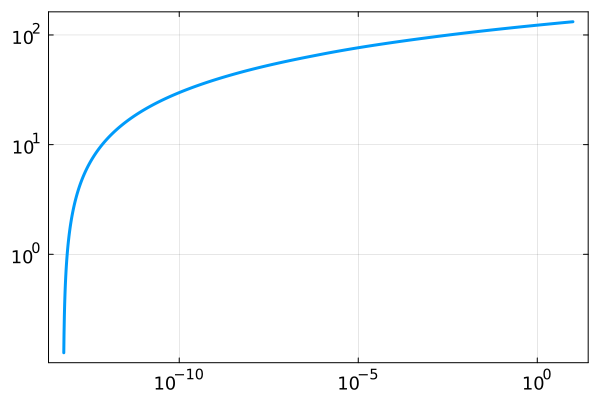

In [87]:
plot(F1sol.t[2:end], F1sol.u[2:end],xscale=:log10,yscale=:log10)

In [91]:
anormList = [anorm(eta) for eta in etalist];
calHList = [calHnorm(eta) for eta in etalist];
EoSwList = [EoSwsol(eta) for eta in etalist];
cs2List = [cs2sol(eta) for eta in etalist];
grhoList = [grhosol(eta) for eta in etalist];
gsList = [gssol(eta) for eta in etalist];
F1List = [F1sol(eta) for eta in etalist];

In [93]:
writedlm("data/bg.csv", hcat(etalist,anormList,calHList,EoSwList,cs2List,grhoList,gsList,F1List), ',');

## load

In [95]:
bgdata = readdlm("data/bg.csv", ',');

etaList = bgdata[:,1];
anormList = bgdata[:,2];
calHList = bgdata[:,3];
EoSwList = bgdata[:,4];
cs2List = bgdata[:,5];
grhoList = bgdata[:,6];
gsList = bgdata[:,7];
F1List = bgdata[:,8];

In [97]:
lnetaList = log10.(etaList);
etai = etaList[1];
etaf = etaList[length(etaList)];

alneta = CubicSpline(anormList, lnetaList)
aint(eta) = alneta(log10(eta))
calHlneta = CubicSpline(calHList, lnetaList)
calHint(eta) = calHlneta(log10(eta));
EoSwlneta = CubicSpline(EoSwList, lnetaList);
EoSwint(eta) = EoSwlneta(log10(eta))
cs2lneta = CubicSpline(cs2List, lnetaList);
cs2int(eta) = cs2lneta(log10(eta));
grholneta = CubicSpline(grhoList, lnetaList);
grhoint(eta) = grholneta(log10(eta))
gslneta = CubicSpline(gsList, lnetaList);
gsint(eta) = gslneta(log10(eta));
F1lneta = CubicSpline(F1List, lnetaList);
F1int(eta) = F1lneta(log10(eta));

In [99]:
(etai, etaf)

(5.780118550237214e-14, 9.893722796014597)

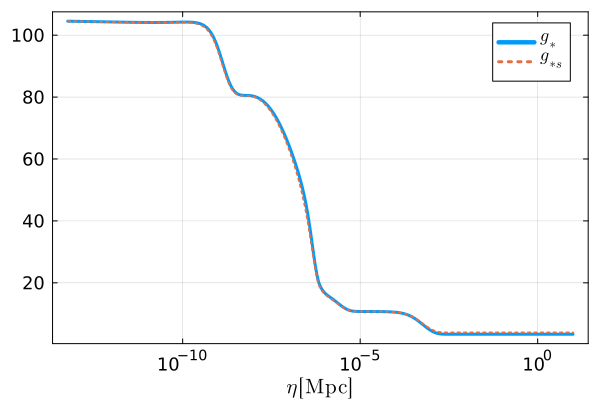

In [101]:
plot(grhoint, etaList, xscale=:log10, label=L"$g_*$", xlabel=L"$\eta\,[\mathrm{Mpc}]$", legend=true)
plot!(gsint, etaList, label=L"$g_{*s}$", linewidth=:2, linestyle=:dot)

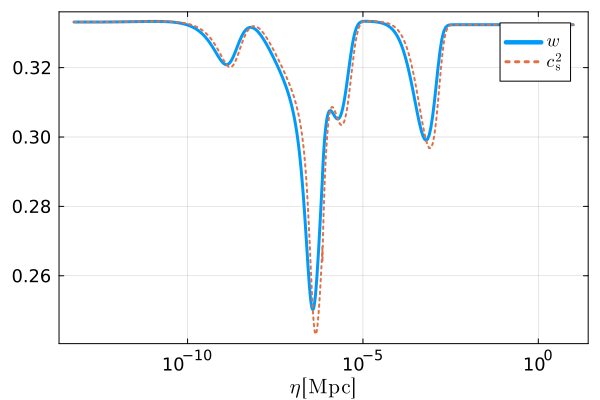

In [103]:
plot(EoSwint, etaList, xscale=:log10, label=L"$w$", xlabel=L"$\eta\,[\mathrm{Mpc}]$", legend=true)
plot!(cs2int, etaList, label=L"$c_\mathrm{s}^2$", linewidth=:2, linestyle=:dot)

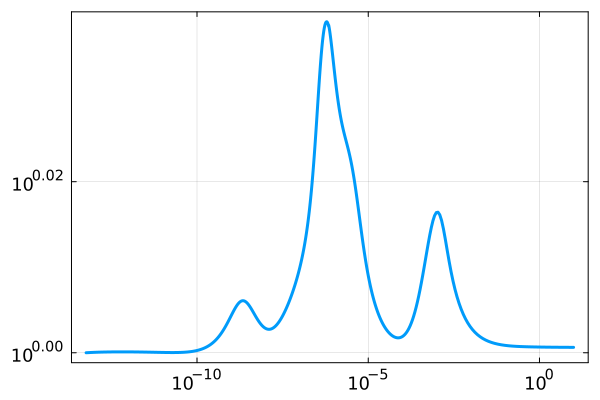

In [105]:
plot(etaList, map(x -> x*calHint(x), etaList), xscale=:log10, yscale=:log10)

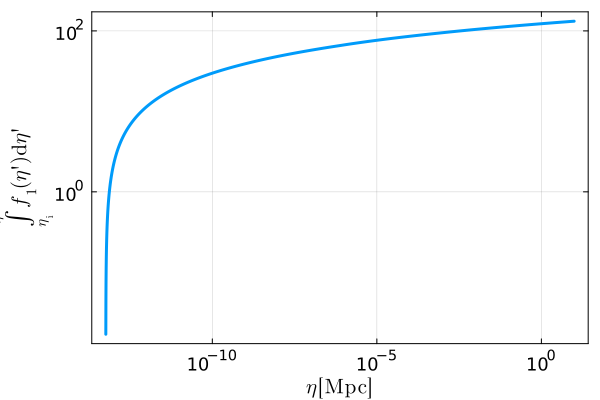

In [115]:
plot(F1int, etaList[2:end], xscale=:log10, yscale=:log10, ylabel=L"$\int_{\eta_\mathrm{i}}^\eta f_1(\eta')\mathrm{d}\eta'$", xlabel=L"$\eta\,[\mathrm{Mpc}]$")

In [117]:
(aint(400/1e5)*calHint(400/1e5)/aint(etaf)/calHint(etaf))^2

0.9773074404160653

In [119]:
etaf/aint(etaf)

463836.5609210441

In [121]:
2.4e4/0.07

342857.14285714284

# Scalar

## calculation

In [198]:
kmin = 1e4
kmax = 1e9
# kList = [10^lnk for lnk=log10(kmin):0.01:log10(kmax)];
kList = [10^lnk for lnk=log10(kmin):log10(kmax)];

In [200]:
f1(eta) = 3*calHint(eta)*(1+cs2int(eta))
f1p(eta) = ForwardDiff.derivative(f1,eta)
f2(eta) = 3*calHint(eta)^2*(cs2int(eta)-EoSwint(eta))
f3(eta) = cs2int(eta)

function omegas(k,eta)
    As = f3(eta)*k^2 + f2(eta) - 1/2 * f1p(eta) - 1/4 * f1(eta)^2
    if As >= 0
        return sqrt(As)
    else
        return im * sqrt(-As)
    end
end

omegasp(k,eta) = ForwardDiff.derivative(etap -> omegas(k,etap), eta)

omegasp (generic function with 1 method)

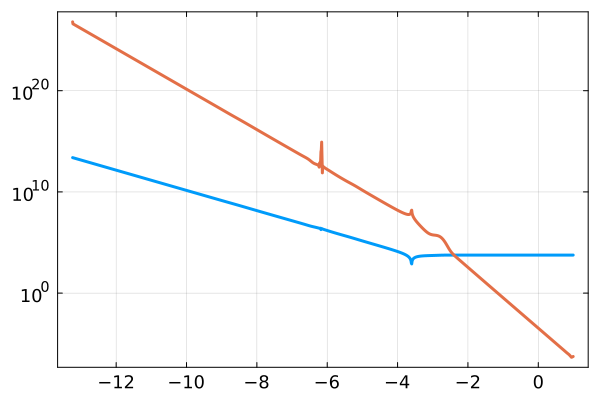

In [260]:
plot(lneta -> abs(omegas(1e4,10^lneta)), log10(etai):0.01:log10(etaf), yscale=:log10)
plot!(lneta -> abs(omegasp(1e4,10^lneta)), log10(etai):0.01:log10(etaf))

In [238]:
# u[i] = C+, u[i+length(kList)] = dC+/deta, u[i+2length(kList)] = C-, u[i+3length(kList)] = dC-/deta, 
# u[i+4length(kList)] = int omegas, p[i] = k
function scalarEoM(du,u,p,eta) 
    Nmode = length(kList)
    
    for i=1:Nmode
        Cp = u[i]
        dCp = u[i+Nmode]
        Cm = u[i+2*Nmode]
        dCm = u[i+3*Nmode]
        k = p[i]
        ws = omegas(k,eta)
        wsp = omegasp(k,eta)
        
        du[i] = dCp
        du[i+Nmode] = - 2*im*ws*dCp - im*wsp*Cp
        du[i+2*Nmode] = dCm
        du[i+3*Nmode] = 2*im*ws*dCm + im*wsp*Cm
        du[i+4*Nmode] = ws
    end
end

ui = vcat([1/2+0*im for i=1:length(kList)], [f1(etai)/4 + 0*im for i=1:length(kList)], 
    [1/2+0*im for i=1:length(kList)], [f1(etai)/4 + 0*im for i=1:length(kList)],
    [0*im for i=1:length(kList)]);

scalarprob = ODEProblem(scalarEoM,ui,(etai,etaf),kList);

In [244]:
omegasp(1e4,1e-4)

0.0 - 1.5525282036698222e8im

In [240]:
@time scalarsol = solve(scalarprob,Tsit5();reltol=1e-10,abstol=1e-10);

  6.261439 seconds (71.96 M allocations: 1.907 GiB, 10.70% gc time, 0.31% compilation time)


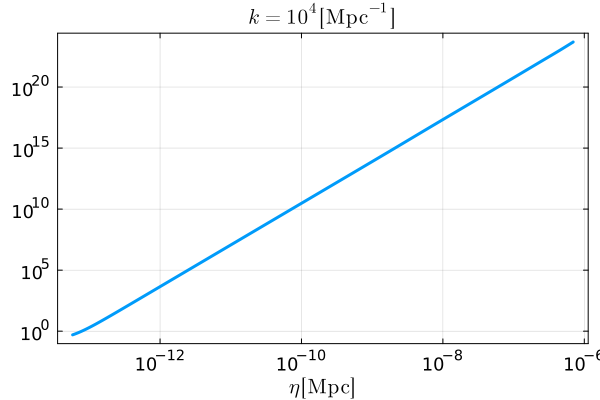

In [242]:
plot(scalarsol.t[2:end], abs.(hcat(scalarsol.u...)[1,2:end]), xscale=:log10, yscale=:log10, xlabel=L"$\eta\,[\mathrm{Mpc}]$", title=L"$k = 10^4\, [\mathrm{Mpc}^{-1}]$")